# CSCI450 Project 2
## **Playing Card Detection**


**Our Team:**

**- Lyudmyla Buhayenko**

**- Sergei Vorobev**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import os
import json

Fill out later: Object detection, what is YOLO, don't want to use a pretrained model so use our own approach. Explain the approach.

### Cropped Subsamples Creation

In [ ]:
dataset_dir = '../Playing Cards.v1-v1.coco'
split_names = ['train', 'valid', 'test']
subsample_dir = '../subsamples'
os.makedirs(subsample_dir, exist_ok=True)

In [2]:
# for split in split_names:
#     os.makedirs(os.path.join(subsample_dir, split), exist_ok=True)

#     with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
#         data = json.load(f)

#     images = {}
#     for img in data['images']:
#         images[img['id']] = img['file_name']
    
#     categories = {}
#     for cat in data['categories']:
#         categories[cat['id']] = cat['name']

#     counter = 0
#     for ann in data['annotations']:
#         filename = images[ann['image_id']]
#         class_name = categories[ann['category_id']]

#         img = io.imread(os.path.join(dataset_dir, split, filename))

#         x = int(ann['bbox'][0])
#         y = int(ann['bbox'][1])
#         w = int(ann['bbox'][2])
#         h = int(ann['bbox'][3])
#         crop = img[y:y+h, x:x+w]

#         class_dir = os.path.join(subsample_dir, split, class_name)
#         os.makedirs(class_dir, exist_ok=True)

#         io.imsave(os.path.join(class_dir, f'{counter}.jpg'), crop)
#         counter += 1

#     print(f'{split}: saved {counter} crops')

train: saved 84789 crops
valid: saved 8080 crops
test: saved 4040 crops


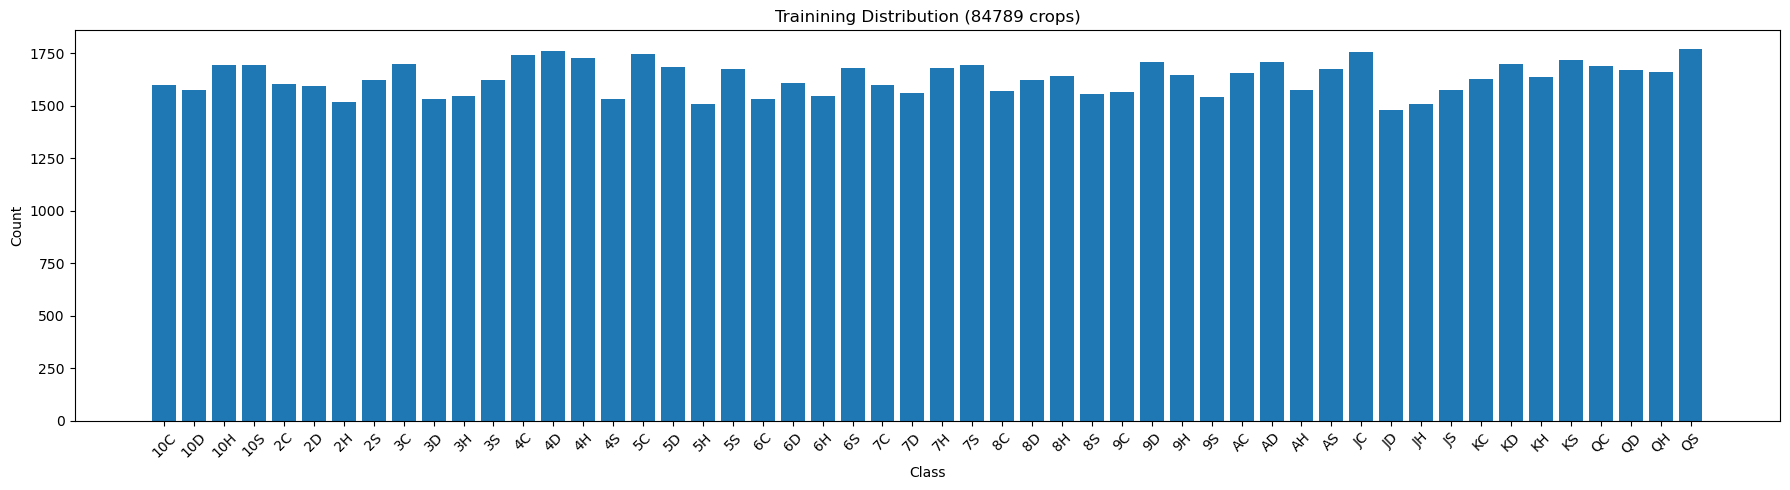

In [7]:
split_path = os.path.join(subsample_dir, 'train')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Trainining Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

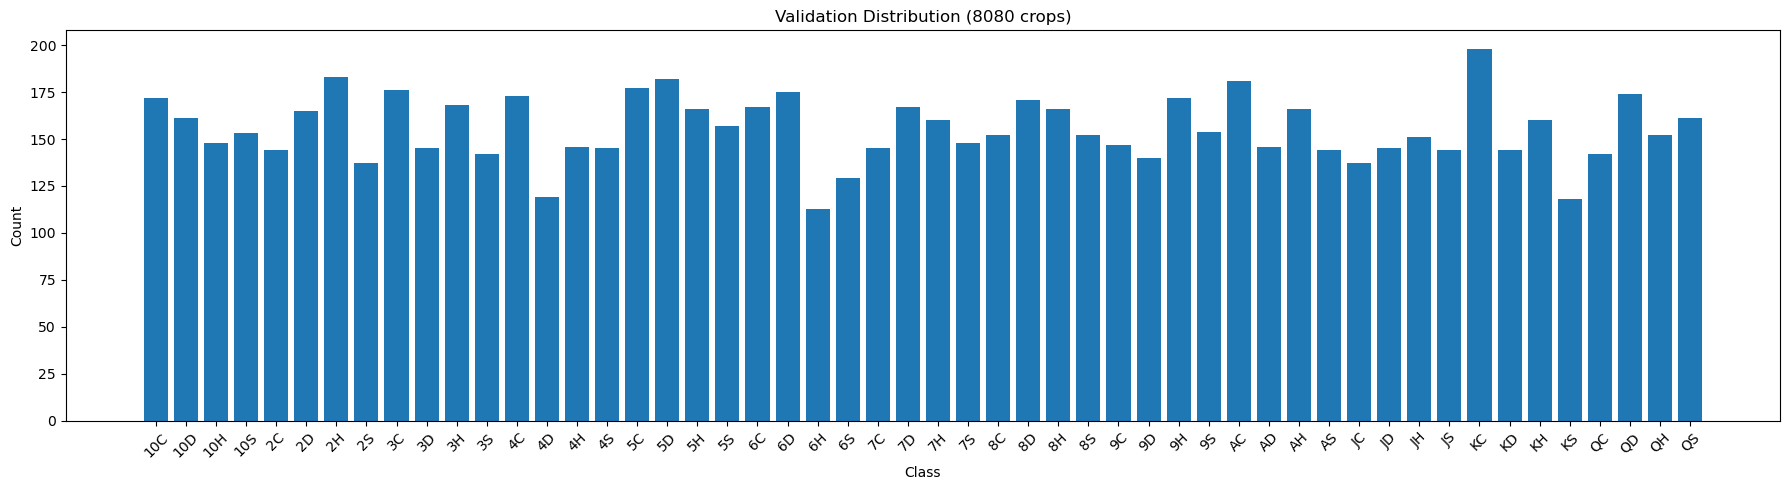

In [8]:
split_path = os.path.join(subsample_dir, 'valid')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Validation Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

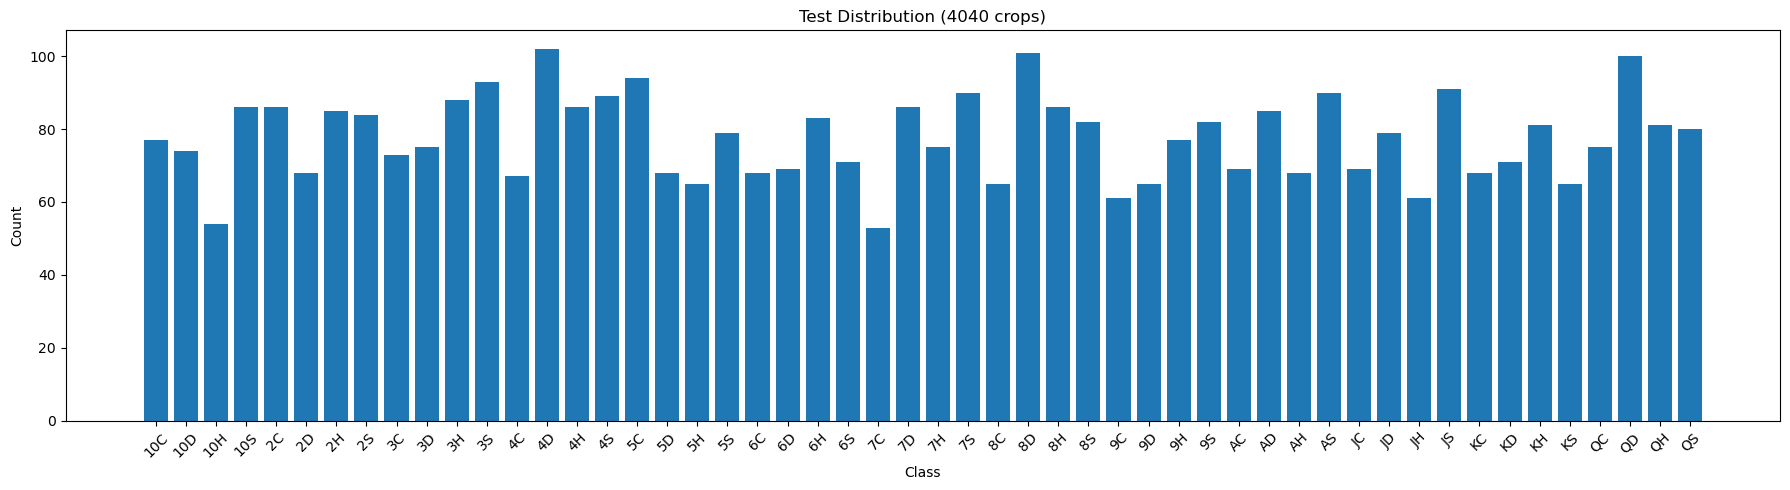

In [9]:
split_path = os.path.join(subsample_dir, 'test')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Test Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### CNN Classification Model

### Card Detection

In [3]:
dataset_dir = '../Playing Cards.v1-v1.coco'
widths = []
heights = []

for split in split_names:
    with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
        data = json.load(f)

    for ann in data['annotations']:
        w = int(ann['bbox'][2])
        h = int(ann['bbox'][3])
        widths.append(w)
        heights.append(h)

print(f"Width --- min: {min(widths)}, max: {max(widths)}, avg: {int(sum(widths)/len(widths))}")
print(f"Height --- min: {min(heights)}, max: {max(heights)}, avg: {int(sum(heights)/len(heights))}")

Width --- min: 7, max: 76, avg: 40
Height --- min: 6, max: 76, avg: 40
